<a href="https://colab.research.google.com/github/danishsuryarirta-create/UAS_Bengkel_Koding/blob/main/UAS_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **UJIAN AKHIR SEMESTER**

---

### **Sales and Marketing**

Nama: Danish Suryarirta Kusuma Yudha

NIM: A11.2023.14873

Kelas: DS-04

Terkait Dataset

Sumber Data : https://www.kaggle.com/datasets/bhaskerpaul/sales-and-marketing-dataset

 Jumlah Sampel Data : Sekitar 15000 data # Jumlah Atribut :30 atribut, meliputi customer, gender,    age, country, object, city, signup_date, last_purchase_date, acquisition_channel,  device_type, subscription_type, is_premium_user, total_visits, avg_session_time, pages_per_session, email_open_rate, email_click_rate, total_spent, avg_order_value, discount_used, coupon_code, support_tickets, refund_requested, delivery_delay_days, payment_method, satisfaction_score, nps_score, marketing_spend_per_user, lifetime_value, last_3_month_purchase_freq

 Variabel target: churn

In [1]:
# !pip install streamlit

In [15]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# BAGIAN 1 — DATA UNDERSTANDING & EDA
### 1.1 Load Dataset & Eksplorasi Awal
> **Tujuan:** Memahami struktur, kualitas, dan pola data sebelum masuk ke pemodelan.

In [3]:
df = pd.read_csv('Sales - Marketing customer dataset.csv')

print("Dataset berhasil dibaca")
print("Jumlah baris dan kolom:", df.shape)

Dataset berhasil dibaca
Jumlah baris dan kolom: (15000, 30)


In [4]:
# 5 baris pertama
print('5 Baris Pertama Dataset:')
df.head()

5 Baris Pertama Dataset:


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [5]:
# 5 baris terakhir
print("===== 5 BARIS TERAKHIR DATASET =====")
display(df.tail())

===== 5 BARIS TERAKHIR DATASET =====


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
14995,24996,Female,24.0,UK,New York,2023-10-23 00:00:00,2024-03-02 00:00:00,Referral,Desktop,Monthly,...,3,0,3,UPI,4.0,2,16.96,796.486833,9,0
14996,24997,Male,26.0,Bangladesh,London,2023-01-20 00:00:00,2024-12-03 00:00:00,Google Ads,Mobile,Monthly,...,3,0,2,BKash,NaN,6,23.86,2155.987233,0,0
14997,24998,Male,42.0,USA,Dhaka,2022-10-11 00:00:00,2023-12-04 00:00:00,Organic,Desktop,Monthly,...,3,0,5,UPI,4.0,4,12.55,614.326226,14,0
14998,24999,Female,31.0,UK,Dhaka,2022-04-01 00:00:00,2024-11-11 00:00:00,Facebook Ads,Desktop,Monthly,...,5,1,1,UPI,3.0,1,19.03,849.936622,8,1
14999,25000,Male,23.0,Bangladesh,Berlin,2023-09-20 00:00:00,2024-06-04 00:00:00,Google Ads,Tablet,Annual,...,1,0,2,PayPal,4.0,4,25.86,1393.092943,8,0


In [6]:
# Informasi dataset (tipe data, non-null count)
print('Info Dataset:')
df.info()

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session

In [7]:
# Statistik deskriptif
print('Statistik Deskriptif:')
df.describe(include='all')

Statistik Deskriptif:


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,14262,13800.000000,15000,15000,15000,15000,15000,15000,15000,...,15000.000000,15000.000000,15000.000000,15000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
unique,NaN,3,NaN,5,7,1000,800,5,3,2,...,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,Germany,London,2024-09-20 00:00:00,2025-01-17 00:00:00,Organic,Tablet,Monthly,...,NaN,NaN,NaN,UPI,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,6844,NaN,3072,2236,29,32,3055,5043,7666,...,NaN,NaN,NaN,3105,NaN,NaN,NaN,NaN,NaN,NaN
mean,17500.500000,NaN,35.203913,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.995600,0.147667,2.981333,NaN,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,NaN,10.334384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.421214,0.354781,1.720537,NaN,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,NaN,-4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,2.000000,NaN,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,0.000000,3.000000,NaN,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,NaN,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,0.000000,4.000000,NaN,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000


### 1.2 Identifikasi Missing Value & Duplikasi Data

In [8]:
#Missing Value
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Jumlah Missing': missing
})

print("Missing Value Sebelum Penanganan")
print(missing_df[missing_df['Jumlah Missing'] > 0])

Missing Value Sebelum Penanganan
                    Jumlah Missing
gender                         738
age                           1200
total_spent                   1050
coupon_code                   6133
satisfaction_score             702


Pada kolom `coupon_code` memiliki ~40% missing value. Karena ini adalah kode kupon yang tidak wajib diisi pelanggan, nilai kosong secara logis berarti *tidak menggunakan kupon* — bukan data yang hilang secara acak. Kolom ini akan di-encode menjadi fitur biner (`has_coupon`) di tahap preprocessing. Kolom `gender`, `age`, dan `satisfaction_score` akan ditangani dengan imputasi.

In [9]:
# Duplikasi
duplikat = df.duplicated().sum()

print("\nJumlah Data Duplikat:", duplikat)


Jumlah Data Duplikat: 0


### 1.3 Distribusi Variabel Target (Churn)

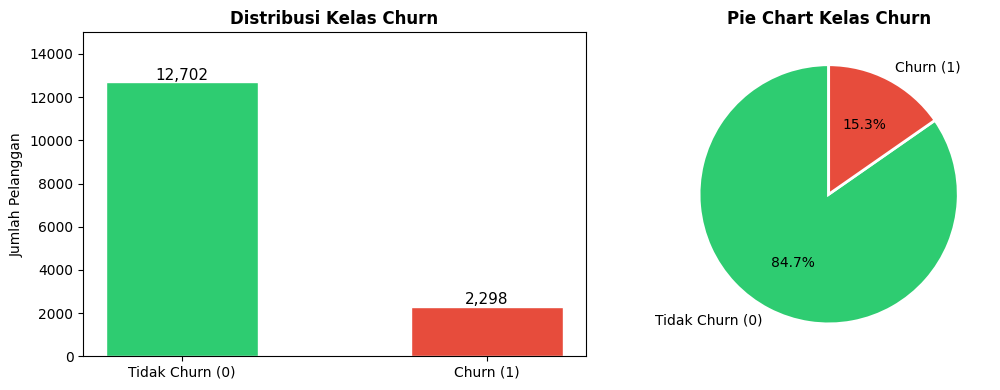

In [10]:
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Tidak Churn (0)', 'Churn (1)'], churn_counts.values, color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=11)
axes[0].set_title('Distribusi Kelas Churn', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].set_ylim(0, 15000)

# Pie chart
axes[1].pie(churn_counts.values, labels=['Tidak Churn (0)', 'Churn (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Pie Chart Kelas Churn', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** Dataset mengalami **class imbalance** — kelas churn (1) hanya sekitar 15.3% dari total data. Kondisi ini harus ditangani agar model tidak bias memprediksi kelas mayoritas (0). Pada tahap preprocessing, akan digunakan **SMOTE** (Synthetic Minority Over-sampling Technique) untuk menyeimbangkan kelas.

### 1.4 Heatmap Korelasi Fitur Numerik


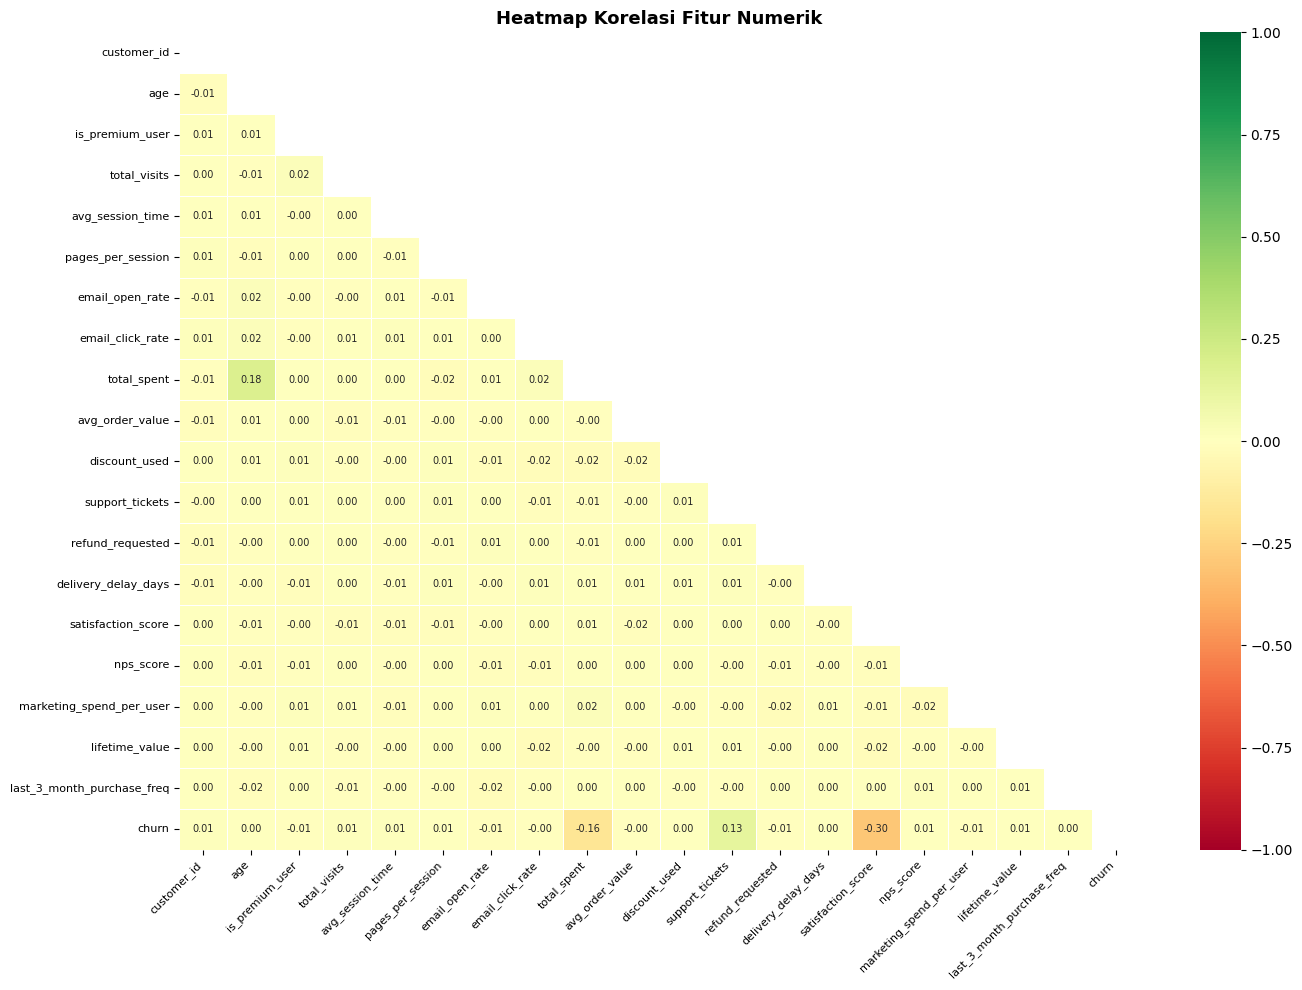


 Korelasi terhadap variabel Churn (urut absolute):
satisfaction_score          0.303588
total_spent                 0.163279
support_tickets             0.127910
total_visits                0.013212
customer_id                 0.012208
avg_session_time            0.012198
email_open_rate             0.008439
marketing_spend_per_user    0.007315
refund_requested            0.006959
lifetime_value              0.006250


In [11]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.4, ax=ax, annot_kws={'size': 7},
            vmin=-1, vmax=1, center=0)
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Top korelasi terhadap churn
print('\n Korelasi terhadap variabel Churn (urut absolute):')
print(corr['churn'].drop('churn').abs().sort_values(ascending=False).head(10).to_string())

**Insight:** Korelasi dilihat untuk mengidentifikasi fitur yang berpotensi redundan (multikolinearitas tinggi) atau sangat berpengaruh terhadap `churn`. Fitur dengan korelasi sangat tinggi satu sama lain bisa dieliminasi untuk mengurangi dimensi.


# BAGIAN 2 — DIRECT MODELING (Baseline)

> **Tujuan:** Melatih model tanpa preprocessing apapun untuk mendapatkan baseline performa. Karena data mentah mengandung kolom kategorikal bertipe object, kolom tersebut perlu di-drop agar model bisa berjalan (namun **tanpa** encoding, scaling, atau penanganan missing value yang proper).

### 2.1 Persiapan Data — Direct (Minimal)

In [12]:
# ── Pisahkan fitur & target ──
# Drop: customer_id (ID tidak informatif), kolom datetime & kategorikal
# Alasan: pada direct modeling, kita hanya bisa pakai kolom numerik
# tanpa transformasi apapun
drop_cols_direct = ['customer_id', 'gender', 'country', 'city',
                    'signup_date', 'last_purchase_date', 'acquisition_channel',
                    'device_type', 'subscription_type', 'coupon_code', 'payment_method']

df_direct = df.drop(columns=drop_cols_direct)

In [13]:
# Isi missing value numerik dengan median (minimal supaya model bisa berjalan)
df_direct = df_direct.fillna(df_direct.median(numeric_only=True))

X_dir = df_direct.drop(columns=['churn'])
y_dir = df_direct['churn']

print(f'Fitur yang digunakan : {X_dir.shape[1]} kolom')
print(f'Kolom: {list(X_dir.columns)}')

Fitur yang digunakan : 18 kolom
Kolom: ['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']


Pada tahap direct modeling, beberapa kolom seperti `gender`, `country`, `city`, `device_type`, `payment_method`, dan kolom kategorikal lainnya dihapus karena model machine learning hanya dapat memproses data numerik secara langsung. Pada skenario ini belum dilakukan preprocessing seperti encoding atau transformasi data kategorikal menjadi numerik. Selain itu, kolom `customer_id` juga dihapus karena hanya berfungsi sebagai identitas unik pelanggan dan tidak memiliki pengaruh terhadap proses prediksi churn. Sementara itu, kolom bertipe datetime seperti `signup_date` dan `last_purchase_date` dihapus karena belum dilakukan ekstraksi fitur waktu seperti durasi berlangganan atau selisih hari transaksi terakhir. Oleh karena itu, direct modeling hanya menggunakan fitur numerik agar model dapat berjalan secara langsung tanpa proses preprocessing tambahan.


### 2.2 Train-Test Split

In [16]:
RANDOM_STATE = 42  # fixed seed untuk reproducibility
TEST_SIZE    = 0.2

X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X_dir, y_dir,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_dir           # jaga proporsi churn di tiap split
)

print(f'Train : {X_train_dir.shape[0]:,} baris | Test : {X_test_dir.shape[0]:,} baris')
print(f'Proporsi Churn — Train: {y_train_dir.mean():.3f} | Test: {y_test_dir.mean():.3f}')

Train : 12,000 baris | Test : 3,000 baris
Proporsi Churn — Train: 0.153 | Test: 0.153


Pada tahap ini dilakukan proses train-test split untuk membagi dataset menjadi data latih (training data) dan data uji (testing data). Pembagian data dilakukan dengan proporsi 80% untuk data latih dan 20% untuk data uji menggunakan parameter `test_size = 0.2`. Selain itu, digunakan `random_state = 42` agar proses pembagian data bersifat reproducible atau menghasilkan pembagian data yang konsisten setiap kali kode dijalankan. Parameter `stratify = y_dir` digunakan untuk menjaga proporsi kelas churn dan non-churn tetap seimbang pada data latih maupun data uji, sehingga distribusi target tidak berubah secara signifikan setelah proses splitting. Langkah ini penting agar model dapat dilatih dan dievaluasi menggunakan distribusi data yang representatif.
